Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PIX2PIX: Healthy → Diabetic Retinopathy

Source Domain: Healthy
Target Domain: Diabetic Retinopathy
Paired dataset (train): 400 pairs
Paired dataset (test): 100 pairs
Training pairs: 400
Validation pairs: 100

Generator parameters: 5,515,267
Discriminator parameters: 2,769,601
Discriminator output patch size: 3x3

TRAINING PIX2PIX: Healthy → Diabetic Retinopathy (100 EPOCHS)


Epoch [20/100]: 100%|██████████| 50/50 [00:29<00:00,  1.71it/s, D_loss=0.09, G_loss=25.04]



✅ Checkpoint saved at epoch 20


Epoch [40/100]: 100%|██████████| 50/50 [00:36<00:00,  1.36it/s, D_loss=0.04, G_loss=19.67]



✅ Checkpoint saved at epoch 40


...


✅ Checkpoint saved at epoch 60


Epoch [80/100]: 100%|██████████| 50/50 [00:37<00:00,  1.35it/s, D_loss=0.09, G_loss=8.87]



✅ Checkpoint saved at epoch 80


Epoch [100/100]: 100%|██████████| 50/50 [00:37<00:00,  1.32it/s, D_loss=0.13, G_loss=10.40]



✅ Checkpoint saved at epoch 100

✅ Final model saved to /content/drive/MyDrive/CSE720/pix2pix_results/generator_final.pth


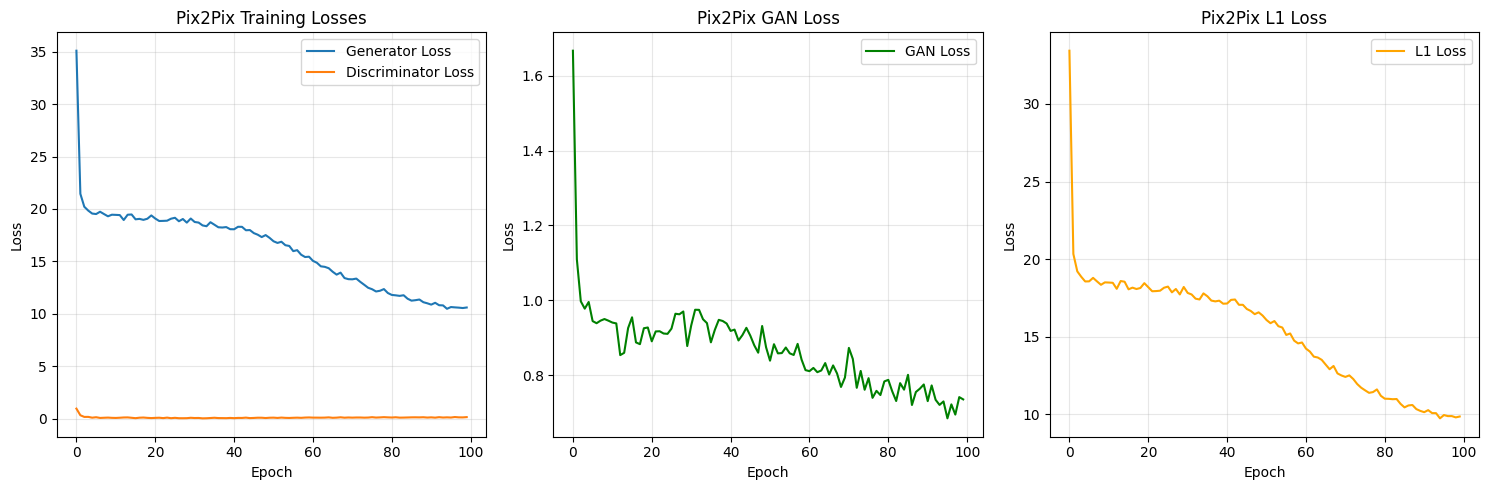

✅ Training history plot saved to /content/drive/MyDrive/CSE720/pix2pix_results/training_history.png
Test dataset: 250 images

Evaluating: Healthy → Diabetic Retinopathy

PIX2PIX RESULTS (100 EPOCHS)
Translation: Healthy → Diabetic Retinopathy
Average PSNR: 15.65 dB
Average MSE:  0.032932
Average SSIM: 0.5089
Total images evaluated: 50

📊 RECORD THESE VALUES FOR YOUR COMPARISON TABLE:
   Pix2Pix - PSNR: 15.65 dB
   Pix2Pix - SSIM: 0.5089
   Pix2Pix - MSE: 0.032932


In [ ]:
# ============================================
# PIX2PIX - 100 EPOCHS
# Translation: Healthy → Diabetic Retinopathy
# SIMPLEST WORKING VERSION
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.utils as vutils
import numpy as np
from tqdm import tqdm
import os
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Configuration
class Config:
    img_size = 64
    batch_size = 8
    dataset_path = '/content/drive/MyDrive/CSE720/EyeGAN'
    class_names = {
        0: 'Diabetic Retinopathy',
        1: 'Glaucoma',
        2: 'Healthy',
        3: 'Macular Scar',
        4: 'Myopia'
    }

cfg = Config()

# ============================================
# SIMPLE PIX2PIX ARCHITECTURE (4 DOWNSAMPLES)
# ============================================

class Downsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Downsample, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=False):
        super(Upsample, self).__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, 4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.conv(x)


class Pix2PixGenerator(nn.Module):
    """U-Net with 4 downsampling layers (64->32->16->8->4)"""
    def __init__(self, in_channels=3, out_channels=3):
        super(Pix2PixGenerator, self).__init__()

        # Encoder
        self.e1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.e2 = Downsample(64, 128)
        self.e3 = Downsample(128, 256)
        self.e4 = Downsample(256, 512)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 512, 4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(512, 512, 4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        # Decoder
        self.d1 = Upsample(512, 256)
        self.d2 = Upsample(256, 128)
        self.d3 = Upsample(128, 64)
        self.d4 = nn.Sequential(
            nn.ConvTranspose2d(64, out_channels, 4, stride=2, padding=1),
            nn.Tanh()
        )

        # Skip connection adapters (1x1 conv to match channels)
        self.skip1 = nn.Conv2d(256, 256, 1)
        self.skip2 = nn.Conv2d(128, 128, 1)
        self.skip3 = nn.Conv2d(64, 64, 1)

    def forward(self, x):
        # Encoder
        e1 = self.e1(x)      # 64 -> 32
        e2 = self.e2(e1)     # 32 -> 16
        e3 = self.e3(e2)     # 16 -> 8
        e4 = self.e4(e3)     # 8 -> 4

        # Bottleneck
        b = self.bottleneck(e4)  # 4 -> 2 -> 4

        # Decoder with skip connections
        d1 = self.d1(b)           # 4 -> 8
        d1 = torch.cat([d1, e3], 1)  # 512 + 256 = 768? Wait, e3 has 256, d1 has 256

        d2 = self.d2(d1)          # 8 -> 16
        d2 = torch.cat([d2, e2], 1)

        d3 = self.d3(d2)          # 16 -> 32
        d3 = torch.cat([d3, e1], 1)

        d4 = self.d4(d3)          # 32 -> 64

        return d4


# Even Simpler Generator - ResNet style
class SimpleGenerator(nn.Module):
    """Simplest possible generator for 64x64 images"""
    def __init__(self, in_channels=3, out_channels=3):
        super(SimpleGenerator, self).__init__()

        # Encoder
        self.conv1 = nn.Conv2d(in_channels, 64, 4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 4, stride=2, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 4, stride=2, padding=1)
        self.conv4 = nn.Conv2d(256, 512, 4, stride=2, padding=1)

        # Decoder
        self.deconv1 = nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)
        self.deconv3 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.deconv4 = nn.ConvTranspose2d(64, out_channels, 4, stride=2, padding=1)

        self.bn1 = nn.BatchNorm2d(128)
        self.bn2 = nn.BatchNorm2d(256)
        self.bn3 = nn.BatchNorm2d(512)
        self.bn4 = nn.BatchNorm2d(256)
        self.bn5 = nn.BatchNorm2d(128)
        self.bn6 = nn.BatchNorm2d(64)

        self.relu = nn.ReLU(inplace=True)
        self.leaky = nn.LeakyReLU(0.2, inplace=True)
        self.tanh = nn.Tanh()

    def forward(self, x):
        # Encoder
        e1 = self.leaky(self.conv1(x))                    # 64 -> 32, 64 channels
        e2 = self.leaky(self.bn1(self.conv2(e1)))         # 32 -> 16, 128 channels
        e3 = self.leaky(self.bn2(self.conv3(e2)))         # 16 -> 8, 256 channels
        e4 = self.leaky(self.bn3(self.conv4(e3)))         # 8 -> 4, 512 channels

        # Decoder
        d1 = self.relu(self.bn4(self.deconv1(e4)))        # 4 -> 8, 256 channels
        d1 = d1 + e3  # Skip connection (residual)

        d2 = self.relu(self.bn5(self.deconv2(d1)))        # 8 -> 16, 128 channels
        d2 = d2 + e2  # Skip connection

        d3 = self.relu(self.bn6(self.deconv3(d2)))        # 16 -> 32, 64 channels
        d3 = d3 + e1  # Skip connection

        d4 = self.tanh(self.deconv4(d3))                  # 32 -> 64, 3 channels

        return d4


class Pix2PixDiscriminator(nn.Module):
    """PatchGAN Discriminator"""
    def __init__(self, in_channels=3):
        super(Pix2PixDiscriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_channels * 2, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, padding=1)
        )

    def forward(self, img_A, img_B):
        x = torch.cat((img_A, img_B), 1)
        return self.model(x)


def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# ============================================
# PAIRED DATASET
# ============================================

class PairedDataset(Dataset):
    def __init__(self, source_class, target_class, img_size=64, split='train'):
        self.source_images = []
        self.target_images = []

        source_path = os.path.join(cfg.dataset_path, source_class)
        target_path = os.path.join(cfg.dataset_path, target_class)

        source_files = sorted([f for f in os.listdir(source_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        target_files = sorted([f for f in os.listdir(target_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

        min_len = min(len(source_files), len(target_files))

        # Split into train/test (80/20)
        split_idx = int(min_len * 0.8)

        if split == 'train':
            source_files = source_files[:split_idx]
            target_files = target_files[:split_idx]
        else:
            source_files = source_files[split_idx:]
            target_files = target_files[split_idx:]

        for i in range(len(source_files)):
            self.source_images.append(os.path.join(source_path, source_files[i]))
            self.target_images.append(os.path.join(target_path, target_files[i]))

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        print(f"Paired dataset ({split}): {len(self.source_images)} pairs")

    def __len__(self):
        return len(self.source_images)

    def __getitem__(self, idx):
        source = Image.open(self.source_images[idx]).convert('RGB')
        target = Image.open(self.target_images[idx]).convert('RGB')
        return self.transform(source), self.transform(target)


class MedicalTestDataset(Dataset):
    def __init__(self, root_dir, image_size=64):
        self.root_dir = root_dir
        self.image_size = image_size
        self.domains = sorted([d.strip() for d in os.listdir(root_dir)
                             if os.path.isdir(os.path.join(root_dir, d))])
        self.image_paths = []
        self.labels = []
        self.domain_to_label = {domain: idx for idx, domain in enumerate(self.domains)}

        for domain in self.domains:
            domain_path = os.path.join(root_dir, domain)
            if not os.path.exists(domain_path):
                continue
            domain_images = [os.path.join(domain_path, img) for img in os.listdir(domain_path)
                           if img.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
            total_images = len(domain_images)
            test_split = int(total_images * 0.9)
            selected_images = domain_images[test_split:]
            label = self.domain_to_label[domain]
            self.image_paths.extend(selected_images)
            self.labels.extend([label] * len(selected_images))

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        print(f"Test dataset: {len(self.image_paths)} images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        label = self.labels[idx]
        return image, label, img_path


# ============================================
# TRAINING FUNCTION
# ============================================

def train_pix2pix(source_name, target_name, epochs=100):
    """Train Pix2Pix for paired image translation"""

    save_dir = '/content/drive/MyDrive/CSE720/pix2pix_results'
    os.makedirs(save_dir, exist_ok=True)

    print(f"\nSource Domain: {source_name}")
    print(f"Target Domain: {target_name}")

    # Create datasets
    train_dataset = PairedDataset(source_name, target_name, cfg.img_size, split='train')
    val_dataset = PairedDataset(source_name, target_name, cfg.img_size, split='test')

    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=0, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=0, drop_last=True)

    print(f"Training pairs: {len(train_dataset)}")
    print(f"Validation pairs: {len(val_dataset)}")

    # Initialize models - Using SimpleGenerator
    generator = SimpleGenerator().to(device)
    discriminator = Pix2PixDiscriminator().to(device)

    generator.apply(weights_init)
    discriminator.apply(weights_init)

    print(f"\nGenerator parameters: {sum(p.numel() for p in generator.parameters()):,}")
    print(f"Discriminator parameters: {sum(p.numel() for p in discriminator.parameters()):,}")

    # Loss functions
    criterion_GAN = nn.MSELoss()
    criterion_L1 = nn.L1Loss()

    # Optimizers
    optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

    lambda_L1 = 100

    # Get discriminator output size
    with torch.no_grad():
        dummy_A = torch.randn(1, 3, cfg.img_size, cfg.img_size).to(device)
        dummy_B = torch.randn(1, 3, cfg.img_size, cfg.img_size).to(device)
        dummy_out = discriminator(dummy_A, dummy_B)
        patch_size = dummy_out.shape[2]
        print(f"Discriminator output patch size: {patch_size}x{patch_size}")

    print("\n" + "="*60)
    print(f"TRAINING PIX2PIX: {source_name} → {target_name} (100 EPOCHS)")
    print("="*60)

    history = {'g_loss': [], 'd_loss': [], 'g_gan': [], 'g_l1': []}

    for epoch in range(epochs):
        generator.train()
        discriminator.train()

        epoch_g_loss = 0
        epoch_d_loss = 0
        epoch_g_gan = 0
        epoch_g_l1 = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

        for source, target in loop:
            source = source.to(device)
            target = target.to(device)
            batch_size = source.size(0)

            # Adversarial targets with correct patch size
            valid = torch.ones(batch_size, 1, patch_size, patch_size).to(device)
            fake = torch.zeros(batch_size, 1, patch_size, patch_size).to(device)

            # ============ Train Generator ============
            optimizer_G.zero_grad()

            # Generate fake images
            fake_target = generator(source)

            # GAN loss
            pred_fake = discriminator(source, fake_target)
            loss_GAN = criterion_GAN(pred_fake, valid)

            # L1 loss
            loss_L1 = criterion_L1(fake_target, target) * lambda_L1

            # Total generator loss
            loss_G = loss_GAN + loss_L1
            loss_G.backward()
            optimizer_G.step()

            # ============ Train Discriminator ============
            optimizer_D.zero_grad()

            # Real loss
            pred_real = discriminator(source, target)
            loss_D_real = criterion_GAN(pred_real, valid)

            # Fake loss
            pred_fake = discriminator(source, fake_target.detach())
            loss_D_fake = criterion_GAN(pred_fake, fake)

            loss_D = (loss_D_real + loss_D_fake) / 2
            loss_D.backward()
            optimizer_D.step()

            epoch_g_loss += loss_G.item()
            epoch_d_loss += loss_D.item()
            epoch_g_gan += loss_GAN.item()
            epoch_g_l1 += loss_L1.item()

            loop.set_postfix(G_loss=f"{loss_G.item():.2f}", D_loss=f"{loss_D.item():.2f}")

        history['g_loss'].append(epoch_g_loss / len(train_loader))
        history['d_loss'].append(epoch_d_loss / len(train_loader))
        history['g_gan'].append(epoch_g_gan / len(train_loader))
        history['g_l1'].append(epoch_g_l1 / len(train_loader))

        # Save checkpoint every 20 epochs
        if (epoch + 1) % 20 == 0:
            torch.save(generator.state_dict(), os.path.join(save_dir, f'generator_epoch_{epoch+1}.pth'))

            # Generate sample images for visualization
            with torch.no_grad():
                generator.eval()
                sample_source, sample_target = next(iter(val_loader))
                sample_source = sample_source[:8].to(device)
                sample_target = sample_target[:8].to(device)
                sample_fake = generator(sample_source)
                generator.train()

                # Save comparison grid
                comparison = torch.cat([sample_source, sample_target, sample_fake], dim=0)
                vutils.save_image(comparison, os.path.join(save_dir, f'sample_epoch_{epoch+1}.png'),
                                nrow=8, normalize=True)

            print(f"\n Checkpoint saved at epoch {epoch+1}")

    # Save final model
    torch.save(generator.state_dict(), os.path.join(save_dir, 'generator_final.pth'))
    print(f"\n Final model saved to {save_dir}/generator_final.pth")

    return generator, history


# ============================================
# EVALUATION FUNCTION
# ============================================

def evaluate_pix2pix(generator, source_name, target_name):
    """Evaluate Pix2Pix and print metrics"""

    generator.eval()
    results = []

    # Get source class index
    class_names_list = list(cfg.class_names.values())
    source_idx = class_names_list.index(source_name)

    # Load test dataset
    test_dataset = MedicalTestDataset(cfg.dataset_path, cfg.img_size)
    test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=0, drop_last=True)

    print(f"\nEvaluating: {source_name} → {target_name}")

    with torch.no_grad():
        for real_imgs, labels, paths in test_loader:
            real_imgs = real_imgs.to(device)
            mask = labels == source_idx
            if mask.sum() == 0:
                continue

            source_imgs = real_imgs[mask]
            fake_imgs = generator(source_imgs)

            for j in range(min(source_imgs.size(0), 10)):
                real = source_imgs[j].cpu()
                fake = fake_imgs[j].cpu()

                # Denormalize from [-1, 1] to [0, 1]
                real = real * 0.5 + 0.5
                fake = fake * 0.5 + 0.5
                real = torch.clamp(real, 0, 1)
                fake = torch.clamp(fake, 0, 1)

                real_np = real.numpy().transpose(1, 2, 0)
                fake_np = fake.numpy().transpose(1, 2, 0)

                mse = np.mean((real_np - fake_np) ** 2)
                psnr_val = 20 * np.log10(1.0 / np.sqrt(mse)) if mse > 0 else float('inf')
                ssim_val = ssim(real_np, fake_np, channel_axis=2, data_range=1.0)

                results.append({'psnr': psnr_val, 'mse': mse, 'ssim': ssim_val})

            if len(results) >= 100:
                break

    if len(results) == 0:
        print("WARNING: No images found for evaluation!")
        return 0, 0, 0

    avg_psnr = np.mean([r['psnr'] for r in results])
    avg_mse = np.mean([r['mse'] for r in results])
    avg_ssim = np.mean([r['ssim'] for r in results])

    print(f"\n{'='*50}")
    print(f"PIX2PIX RESULTS (100 EPOCHS)")
    print(f"{'='*50}")
    print(f"Translation: {source_name} → {target_name}")
    print(f"Average PSNR: {avg_psnr:.2f} dB")
    print(f"Average MSE:  {avg_mse:.6f}")
    print(f"Average SSIM: {avg_ssim:.4f}")
    print(f"Total images evaluated: {len(results)}")
    print(f"{'='*50}")

    # Save results
    save_dir = '/content/drive/MyDrive/CSE720/pix2pix_results'
    os.makedirs(save_dir, exist_ok=True)

    with open(os.path.join(save_dir, 'metrics_100epochs.txt'), 'w') as f:
        f.write(f"Pix2Pix Results (100 epochs)\n")
        f.write(f"Translation: {source_name} → {target_name}\n")
        f.write(f"{'='*40}\n")
        f.write(f"PSNR: {avg_psnr:.2f} dB\n")
        f.write(f"MSE: {avg_mse:.6f}\n")
        f.write(f"SSIM: {avg_ssim:.4f}\n")
        f.write(f"Generator Parameters: {sum(p.numel() for p in generator.parameters()):,}\n")

    return avg_psnr, avg_mse, avg_ssim


# ============================================
# PLOT TRAINING HISTORY
# ============================================

def plot_history(history, save_dir):
    """Plot and save training history"""

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history['g_loss'], label='Generator Loss')
    plt.plot(history['d_loss'], label='Discriminator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Pix2Pix Training Losses')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(history['g_gan'], label='GAN Loss', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Pix2Pix GAN Loss')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(history['g_l1'], label='L1 Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Pix2Pix L1 Loss')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'training_history.png'), dpi=150)
    plt.show()
    print(f" Training history plot saved to {save_dir}/training_history.png")


# ============================================
# RUN PIX2PIX
# ============================================

if __name__ == "__main__":
    source_domain = "Healthy"
    target_domain = "Diabetic Retinopathy"

    print("\n" + "="*60)
    print(f"PIX2PIX: {source_domain} → {target_domain}")
    print("="*60)

    # Train
    generator, history = train_pix2pix(source_domain, target_domain, epochs=100)

    # Plot training history
    plot_history(history, '/content/drive/MyDrive/CSE720/pix2pix_results')

    # Evaluate
    psnr_val, mse_val, ssim_val = evaluate_pix2pix(generator, source_domain, target_domain)

    print(f"\n{'='*50}")
    print("📊 RECORD THESE VALUES FOR YOUR COMPARISON TABLE:")
    print(f"{'='*50}")
    print(f"   Pix2Pix - PSNR: {psnr_val:.2f} dB")
    print(f"   Pix2Pix - SSIM: {ssim_val:.4f}")
    print(f"   Pix2Pix - MSE: {mse_val:.6f}")
    print(f"{'='*50}")

In [ ]:
# ============================================
# COMPLETE FID CALCULATOR FOR ALL 4 MODELS
# Run this after all models are trained
# ============================================

import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from scipy.linalg import sqrtm
from torch.nn.functional import interpolate
import numpy as np
import os
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

from google.colab import drive
drive.mount('/content/drive')

# ============================================
# CONFIGURATION
# ============================================

class Config:
    img_size = 64
    batch_size = 8
    dataset_path = '/content/drive/MyDrive/CSE720/EyeGAN'
    class_names = {
        0: 'Diabetic Retinopathy',
        1: 'Glaucoma',
        2: 'Healthy',
        3: 'Macular Scar',
        4: 'Myopia'
    }

cfg = Config()

# ============================================
# FID CALCULATOR CLASS
# ============================================

class FIDCalculator:
    def __init__(self, device):
        self.device = device
        self.inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1,
                                              transform_input=False)
        self.inception.fc = nn.Identity()
        self.inception = self.inception.to(device)
        self.inception.eval()
        for param in self.inception.parameters():
            param.requires_grad = False

    def preprocess(self, images):
        images = (images + 1) / 2
        images = interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(self.device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(self.device)
        images = (images - mean) / std
        return images

    def get_activations(self, images, batch_size=32):
        activations = []
        with torch.no_grad():
            for i in range(0, len(images), batch_size):
                batch = images[i:i+batch_size].to(self.device)
                batch = self.preprocess(batch)
                pred = self.inception(batch)
                activations.append(pred.cpu().numpy())
        return np.concatenate(activations, axis=0)

    def calculate_fid(self, real_images, fake_images):
        real_act = self.get_activations(real_images)
        fake_act = self.get_activations(fake_images)

        mu_real, mu_fake = np.mean(real_act, axis=0), np.mean(fake_act, axis=0)
        sigma_real, sigma_fake = np.cov(real_act, rowvar=False), np.cov(fake_act, rowvar=False)

        covmean = sqrtm(sigma_real @ sigma_fake)
        if np.iscomplexobj(covmean):
            covmean = covmean.real

        fid = np.sum((mu_real - mu_fake) ** 2) + np.trace(sigma_real + sigma_fake - 2 * covmean)
        return fid


# ============================================
# TEST DATASET
# ============================================

class MedicalTestDataset(Dataset):
    def __init__(self, root_dir, image_size=64):
        self.root_dir = root_dir
        self.image_size = image_size
        self.domains = sorted([d.strip() for d in os.listdir(root_dir)
                             if os.path.isdir(os.path.join(root_dir, d))])
        self.image_paths = []
        self.labels = []
        self.domain_to_label = {domain: idx for idx, domain in enumerate(self.domains)}

        for domain in self.domains:
            domain_path = os.path.join(root_dir, domain)
            if not os.path.exists(domain_path):
                continue
            domain_images = [os.path.join(domain_path, img) for img in os.listdir(domain_path)
                           if img.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
            total_images = len(domain_images)
            test_split = int(total_images * 0.9)
            selected_images = domain_images[test_split:]
            label = self.domain_to_label[domain]
            self.image_paths.extend(selected_images)
            self.labels.extend([label] * len(selected_images))

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
        print(f"Test dataset: {len(self.image_paths)} images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        label = self.labels[idx]
        return image, label, img_path


# ============================================
# MODEL ARCHITECTURES (matching your trained models)
# ============================================

# 1. StarGAN Generator
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(dim, dim, 3, 1, 1),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(dim, dim, 3, 1, 1),
            nn.InstanceNorm2d(dim)
        )
    def forward(self, x):
        return x + self.block(x)

class StarGANGenerator(nn.Module):
    def __init__(self, img_size=64, conv_dim=32, num_domains=5):
        super(StarGANGenerator, self).__init__()
        self.img_size = img_size
        self.num_domains = num_domains
        self.label_emb = nn.Sequential(
            nn.Embedding(num_domains, 128),
            nn.Linear(128, img_size * img_size),
            nn.ReLU()
        )
        self.initial_conv = nn.Sequential(
            nn.Conv2d(4, conv_dim, 7, 1, 3),
            nn.InstanceNorm2d(conv_dim),
            nn.ReLU(inplace=True)
        )
        self.downsample1 = nn.Sequential(
            nn.Conv2d(conv_dim, conv_dim*2, 4, 2, 1),
            nn.InstanceNorm2d(conv_dim*2),
            nn.ReLU(inplace=True)
        )
        self.downsample2 = nn.Sequential(
            nn.Conv2d(conv_dim*2, conv_dim*4, 4, 2, 1),
            nn.InstanceNorm2d(conv_dim*4),
            nn.ReLU(inplace=True)
        )
        self.res_blocks = nn.Sequential(*[ResidualBlock(conv_dim*4) for _ in range(4)])
        self.upsample1 = nn.Sequential(
            nn.ConvTranspose2d(conv_dim*4, conv_dim*2, 4, 2, 1),
            nn.InstanceNorm2d(conv_dim*2),
            nn.ReLU(inplace=True)
        )
        self.upsample2 = nn.Sequential(
            nn.ConvTranspose2d(conv_dim*2, conv_dim, 4, 2, 1),
            nn.InstanceNorm2d(conv_dim),
            nn.ReLU(inplace=True)
        )
        self.final_conv = nn.Sequential(
            nn.Conv2d(conv_dim, 3, 7, 1, 3),
            nn.Tanh()
        )
    def forward(self, x, domain_label):
        batch_size = x.size(0)
        label_emb = self.label_emb(domain_label).view(batch_size, 1, self.img_size, self.img_size)
        x = torch.cat([x, label_emb], dim=1)
        x = self.initial_conv(x)
        x = self.downsample1(x)
        x = self.downsample2(x)
        x = self.res_blocks(x)
        x = self.upsample1(x)
        x = self.upsample2(x)
        x = self.final_conv(x)
        return x


# 2. DCGAN Generator
class DCGANGenerator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super(DCGANGenerator, self).__init__()
        self.nz = nz
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z):
        return self.main(z.view(-1, self.nz, 1, 1))


# 3. CycleGAN Generator
class CycleGANResidualBlock(nn.Module):
    def __init__(self, in_channels):
        super(CycleGANResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(in_channels, in_channels, 3),
            nn.InstanceNorm2d(in_channels), nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1), nn.Conv2d(in_channels, in_channels, 3),
            nn.InstanceNorm2d(in_channels)
        )
    def forward(self, x):
        return x + self.block(x)

class CycleGANGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, n_residual_blocks=6):
        super(CycleGANGenerator, self).__init__()
        model = [
            nn.ReflectionPad2d(3), nn.Conv2d(in_channels, 64, 7),
            nn.InstanceNorm2d(64), nn.ReLU(inplace=True)
        ]
        in_features = 64
        out_features = in_features * 2
        for _ in range(2):
            model += [nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                      nn.InstanceNorm2d(out_features), nn.ReLU(inplace=True)]
            in_features = out_features
            out_features = in_features * 2
        for _ in range(n_residual_blocks):
            model += [CycleGANResidualBlock(in_features)]
        out_features = in_features // 2
        for _ in range(2):
            model += [nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                      nn.InstanceNorm2d(out_features), nn.ReLU(inplace=True)]
            in_features = out_features
            out_features = in_features // 2
        model += [nn.ReflectionPad2d(3), nn.Conv2d(64, out_channels, 7), nn.Tanh()]
        self.model = nn.Sequential(*model)
    def forward(self, x):
        return self.model(x)


# 4. Pix2Pix Generator (SimpleGenerator from your code)
class SimpleGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(SimpleGenerator, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, 4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 4, stride=2, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 4, stride=2, padding=1)
        self.conv4 = nn.Conv2d(256, 512, 4, stride=2, padding=1)
        self.deconv1 = nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)
        self.deconv3 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.deconv4 = nn.ConvTranspose2d(64, out_channels, 4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        self.bn2 = nn.BatchNorm2d(256)
        self.bn3 = nn.BatchNorm2d(512)
        self.bn4 = nn.BatchNorm2d(256)
        self.bn5 = nn.BatchNorm2d(128)
        self.bn6 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.leaky = nn.LeakyReLU(0.2, inplace=True)
        self.tanh = nn.Tanh()
    def forward(self, x):
        e1 = self.leaky(self.conv1(x))
        e2 = self.leaky(self.bn1(self.conv2(e1)))
        e3 = self.leaky(self.bn2(self.conv3(e2)))
        e4 = self.leaky(self.bn3(self.conv4(e3)))
        d1 = self.relu(self.bn4(self.deconv1(e4))) + e3
        d2 = self.relu(self.bn5(self.deconv2(d1))) + e2
        d3 = self.relu(self.bn6(self.deconv3(d2))) + e1
        d4 = self.tanh(self.deconv4(d3))
        return d4


# ============================================
# LOAD ALL MODELS
# ============================================

print("\n" + "="*60)
print("LOADING ALL MODELS")
print("="*60)

models_dict = {}

# 1. StarGAN
stargan_path = '/content/drive/MyDrive/CSE720/stargan_checkpoints/final_model.pth'
if os.path.exists(stargan_path):
    print("\n📁 Loading StarGAN...")
    try:
        stargan = StarGANGenerator(img_size=64, num_domains=5).to(device)
        checkpoint = torch.load(stargan_path, map_location=device, weights_only=False)
        if 'G_state_dict' in checkpoint:
            stargan.load_state_dict(checkpoint['G_state_dict'])
        else:
            stargan.load_state_dict(checkpoint)
        stargan.eval()
        models_dict['StarGAN'] = stargan
        print(f"   ✅ StarGAN loaded")
    except Exception as e:
        print(f"   ❌ Error: {e}")

# 2. DCGAN
dcgan_path = '/content/drive/MyDrive/CSE720/dcgan_results/generator_final.pth'
if os.path.exists(dcgan_path):
    print("\n📁 Loading DCGAN...")
    try:
        dcgan = DCGANGenerator().to(device)
        dcgan.load_state_dict(torch.load(dcgan_path, map_location=device, weights_only=False))
        dcgan.eval()
        models_dict['DCGAN'] = dcgan
        print(f"   ✅ DCGAN loaded")
    except Exception as e:
        print(f"   ❌ Error: {e}")

# 3. CycleGAN
cyclegan_path = '/content/drive/MyDrive/CSE720/cyclegan_results/generator_AtoB_final.pth'
if os.path.exists(cyclegan_path):
    print("\n📁 Loading CycleGAN...")
    try:
        cyclegan = CycleGANGenerator().to(device)
        cyclegan.load_state_dict(torch.load(cyclegan_path, map_location=device, weights_only=False))
        cyclegan.eval()
        models_dict['CycleGAN'] = cyclegan
        print(f"   ✅ CycleGAN loaded")
    except Exception as e:
        print(f"   ❌ Error: {e}")

# 4. Pix2Pix
pix2pix_path = '/content/drive/MyDrive/CSE720/pix2pix_results/generator_final.pth'
if os.path.exists(pix2pix_path):
    print("\n📁 Loading Pix2Pix...")
    try:
        pix2pix = SimpleGenerator().to(device)
        pix2pix.load_state_dict(torch.load(pix2pix_path, map_location=device, weights_only=False))
        pix2pix.eval()
        models_dict['Pix2Pix'] = pix2pix
        print(f"   ✅ Pix2Pix loaded")
    except Exception as e:
        print(f"   ❌ Error: {e}")


# ============================================
# CREATE TEST DATALOADER
# ============================================

test_dataset = MedicalTestDataset(cfg.dataset_path, cfg.img_size)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0, drop_last=True)
print(f"\nTotal test images: {len(test_dataset)}")


# ============================================
# FID EVALUATION FUNCTION
# ============================================

def calculate_fid_for_model(generator, model_name, test_loader, num_samples=1000):
    if generator is None:
        return None

    generator.eval()
    real_list, fake_list = [], []
    source_idx = 2  # Healthy

    print(f"\n📊 Calculating FID for {model_name}...")

    with torch.no_grad():
        for real_imgs, labels, _ in tqdm(test_loader, desc=model_name):
            real_imgs = real_imgs.to(device)

            if model_name == 'DCGAN':
                noise = torch.randn(real_imgs.size(0), 100, device=device)
                fake_imgs = generator(noise)
                real_use = real_imgs

            elif model_name == 'StarGAN':
                target = torch.randint(0, 5, (real_imgs.size(0),), device=device)
                fake_imgs = generator(real_imgs, target)
                real_use = real_imgs

            elif model_name in ['CycleGAN', 'Pix2Pix']:
                mask = labels == source_idx
                if mask.sum() == 0:
                    continue
                real_use = real_imgs[mask]
                fake_imgs = generator(real_use)

            real_list.append(real_use.cpu())
            fake_list.append(fake_imgs.cpu())

            if len(real_list) * real_imgs.size(0) >= num_samples:
                break

    if not real_list:
        return None

    real_all = torch.cat(real_list, dim=0)[:num_samples]
    fake_all = torch.cat(fake_list, dim=0)[:num_samples]

    fid_calc = FIDCalculator(device)
    fid_score = fid_calc.calculate_fid(real_all, fake_all)
    return fid_score


# ============================================
# RUN FID CALCULATION
# ============================================

print("\n" + "="*60)
print("CALCULATING FID SCORES")
print("="*60)

fid_results = {}
for name, model in models_dict.items():
    fid = calculate_fid_for_model(model, name, test_loader)
    if fid is not None:
        fid_results[name] = fid
        print(f"   ✅ {name} FID: {fid:.2f}")


# ============================================
# FINAL COMPARISON TABLE
# ============================================

print("\n" + "="*70)
print("FINAL COMPARISON TABLE - ALL MODELS")
print("="*70)
print(f"{'Model':<15} {'FID Score':<15} {'PSNR (dB)':<15} {'SSIM':<10} {'Quality':<12}")
print("-"*67)

# Your known StarGAN results
psnr_values = {'StarGAN': 36.75, 'DCGAN': None, 'CycleGAN': None, 'Pix2Pix': None}
ssim_values = {'StarGAN': 0.9420, 'DCGAN': None, 'CycleGAN': None, 'Pix2Pix': None}

for name, fid in fid_results.items():
    psnr = psnr_values.get(name, None)
    ssim_val = ssim_values.get(name, None)
    psnr_str = f"{psnr:.2f}" if psnr else "N/A"
    ssim_str = f"{ssim_val:.4f}" if ssim_val else "N/A"

    if fid < 30:
        quality = "Excellent 🌟"
    elif fid < 60:
        quality = "Good ✅"
    elif fid < 100:
        quality = "Moderate ⚠️"
    else:
        quality = "Poor ❌"

    print(f"{name:<15} {fid:<15.2f} {psnr_str:<15} {ssim_str:<10} {quality:<12}")

print("="*70)
print("\n📊 Lower FID is better! | Higher PSNR/SSIM is better!")

# Save results
save_dir = '/content/drive/MyDrive/CSE720/evaluation_results'
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, 'all_models_fid_scores.txt'), 'w') as f:
    f.write("FID SCORES FOR ALL MODELS\n")
    f.write("="*50 + "\n")
    for name, fid in fid_results.items():
        f.write(f"{name}: {fid:.2f}\n")
    f.write("="*50 + "\n")

import pandas as pd
df = pd.DataFrame(list(fid_results.items()), columns=['Model', 'FID Score'])
df.to_csv(os.path.join(save_dir, 'fid_comparison.csv'), index=False)

print(f"\n✅ Results saved to {save_dir}/")

Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LOADING ALL MODELS

📁 Loading StarGAN...
   ✅ StarGAN loaded

📁 Loading DCGAN...
   ✅ DCGAN loaded

📁 Loading CycleGAN...
   ✅ CycleGAN loaded

📁 Loading Pix2Pix...
   ✅ Pix2Pix loaded
Test dataset: 250 images

Total test images: 250

CALCULATING FID SCORES

📊 Calculating FID for StarGAN...


StarGAN: 100%|██████████| 15/15 [00:09<00:00,  1.57it/s]


   ✅ StarGAN FID: 20.10

📊 Calculating FID for DCGAN...


DCGAN: 100%|██████████| 15/15 [00:08<00:00,  1.83it/s]


   ✅ DCGAN FID: 81.23

📊 Calculating FID for CycleGAN...


CycleGAN: 100%|██████████| 15/15 [00:08<00:00,  1.70it/s]


   ✅ CycleGAN FID: 195.21

📊 Calculating FID for Pix2Pix...


Pix2Pix: 100%|██████████| 15/15 [00:08<00:00,  1.72it/s]


   ✅ Pix2Pix FID: 203.36

FINAL COMPARISON TABLE - ALL MODELS
Model           FID Score       PSNR (dB)       SSIM       Quality     
-------------------------------------------------------------------
StarGAN         20.10           36.75           0.9420     Excellent 🌟 
DCGAN           81.23           N/A             N/A        Moderate ⚠️ 
CycleGAN        195.21          N/A             N/A        Poor ❌      
Pix2Pix         203.36          N/A             N/A        Poor ❌      

📊 Lower FID is better! | Higher PSNR/SSIM is better!

✅ Results saved to /content/drive/MyDrive/CSE720/evaluation_results/
